# Figure reproduction

Regenerates every simulation-based panel from raw data, `figure-data/bursty_transcription_data.pkl`.

Panels are grouped by manuscript figure

| Figure | Panel | Files | Source |
|--------|-------|-------|--------|
| 1 | I | `1I_no`, `1I_yes` | Illustrative simulation trajectories (`figure-data/illustrative_burst_traces.npz`) |
| 2 | B | `2B`, `2B_wide` | Simulation |
| 2 | C | `2C_black` | Simulation |
| 4 | A | `4A` | Simulation |
| 4 | C | `4C_black` | Simulation |
| 5 | A | `5A` | Simulation |
| 5 | C | `5C_black` | Simulation |

Figures are written to a dated subfolder of `Output/`.

# Setup

In [38]:
import os
import pickle
from datetime import date
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

FIGURES_DIR = Path.cwd()
OUT = FIGURES_DIR / 'Output' / date.today().strftime('%Y%m%d')


## Plotting helpers

In [39]:
COLOR_CONDENSATE = '#2d8a4e'
COLOR_BINDING = '#555555'
FONT = {'axis_label': 13, 'tick': 11, 'line_label': 12}
LINE_WIDTH = 3.2
TRACE_COLOR = '#333333'
TRACE_LW = 1.4
TRACE_ALPHA = 0.25

THRESH_WT = 1.0
XLIM_NARROW = (0.5, 2.0)
XLIM_WIDE = (0.1, 10.0)

THRESH_COLOR = (0.45, 0.45, 0.45)
THRESH_LW = 1.6
THRESH_DASH = (1.2, 2.2)

FIG_W = 3.8
FIG_H = 3.4
EXTRA_W = 1.1

LABEL_COND = 'Condensing'
LABEL_BIND = 'Soluble'

YLABEL_FREQ = r'Frequency of activation (time$^{-1}$)'


def apply_mpl_style():
    """Set global matplotlib rcParams for paper figures."""
    plt.rc('font', family='Arial')
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42
    mpl.rcParams['font.size'] = 14
    mpl.rcParams['axes.linewidth'] = 0.75
    mpl.rcParams['lines.linewidth'] = 1.0
    mpl.rcParams['xtick.major.width'] = 0.75
    mpl.rcParams['ytick.major.width'] = 0.75


# Scatter panels only; line panels use make_nice_axis_open.
def make_nice_axis_full(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.75)
    ax.xaxis.set_tick_params(pad=6, direction='in')
    ax.yaxis.set_tick_params(pad=6, direction='in')


def make_nice_axis_open(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.75)
    ax.spines['left'].set_linewidth(0.75)
    ax.xaxis.set_tick_params(pad=6, direction='in')
    ax.yaxis.set_tick_params(pad=6, direction='in')


def apply_log_xaxis_narrow(ax):
    ax.set_xscale('log')
    ax.set_xlim(XLIM_NARROW)
    ax.xaxis.set_major_locator(mticker.FixedLocator([0.5, 1.0, 2.0]))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(['0.5', '1', '2']))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel(r'$[\mathrm{CoF}]_\mathrm{nucleus}$', fontsize=FONT['axis_label'])


def apply_log_xaxis_wide(ax):
    ax.set_xscale('log')
    ax.set_xlim(XLIM_WIDE)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10, numticks=5))
    ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel(r'$[\mathrm{CoF}]_\mathrm{nucleus}$', fontsize=FONT['axis_label'])


def add_threshold_line(ax):
    ax.axvline(
        THRESH_WT, color=THRESH_COLOR, linewidth=THRESH_LW,
        linestyle='--', dashes=THRESH_DASH, zorder=1,
    )

In [40]:
"""Panel builders for the paper figures.

Each `build_*` function returns a Matplotlib `Figure` for a single panel so it can be
displayed inline in a notebook before saving.
"""


def save_figure(fig, out_dir, stem):
    """Write `fig` to `{out_dir}/{stem}.png` and `.pdf`. Does not close `fig`."""
    os.makedirs(out_dir, exist_ok=True)
    for ext, dpi in [('png', 300), ('pdf', 600)]:
        fig.savefig(os.path.join(out_dir, f'{stem}.{ext}'), dpi=dpi, bbox_inches='tight')
    print(f'  saved  {stem}')


def _build_trace(bursts, n_time=500):
    x, y = [0], [0.0]
    for s, e, h in bursts:
        x += [s, s, e, e]
        y += [0, h, h, 0.0]
    x.append(n_time)
    y.append(0.0)
    return np.array(x), np.array(y)


def trajectory_y_top():
    """Shared y-axis ceiling so the no-condensation and condensation traces are comparable."""
    return max(h for _, _, h in BURSTS_YES) * 1.08


def build_trajectory_trace(bursts, y_top):
    """Schematic burst trace (panels 1I_no / 1I_yes)."""
    x, y = _build_trace(bursts)
    fig, ax = plt.subplots(figsize=(6.0, 2.2))
    ax.fill_between(x, y, color=TRACE_COLOR, alpha=TRACE_ALPHA, linewidth=0)
    ax.plot(x, y, color=TRACE_COLOR, linewidth=TRACE_LW,
            solid_joinstyle='miter', solid_capstyle='butt')
    ax.set_xlim(0, 500)
    ax.set_ylim(0, y_top)
    ax.set_xlabel('Time', fontsize=FONT['axis_label'])
    ax.set_ylabel('Gene Activity', fontsize=FONT['axis_label'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_tick_params(direction='in')
    ax.yaxis.set_tick_params(direction='in')
    fig.tight_layout()
    return fig


def build_line_panel(rebin, ylabel):
    """Binding vs. condensate mean line panel (narrow CoF range), open-box style
    with inline line labels instead of a legend.
    """
    x_bins, bind_y, cond_y = rebin['x'], rebin['bm'], rebin['cm']
    fig_w = FIG_W + EXTRA_W

    fig, ax = plt.subplots(figsize=(fig_w, FIG_H))
    ax.plot(x_bins, bind_y, '-', color=COLOR_BINDING, linewidth=LINE_WIDTH, zorder=3)
    ax.plot(x_bins, cond_y, '-', color=COLOR_CONDENSATE, linewidth=LINE_WIDTH, zorder=3)
    add_threshold_line(ax)
    ax.set_ylabel(ylabel, fontsize=FONT['axis_label'])
    ax.set_ylim(bottom=0)
    make_nice_axis_open(ax)
    apply_log_xaxis_narrow(ax)
    fig.tight_layout()

    fig.subplots_adjust(right=FIG_W / (FIG_W + EXTRA_W))
    for y_arr, label, color in [
        (bind_y, LABEL_BIND, COLOR_BINDING),
        (cond_y, LABEL_COND, COLOR_CONDENSATE),
    ]:
        valid = np.where(np.isfinite(y_arr))[0]
        if len(valid) == 0:
            continue
        ax.annotate(
            label, xy=(x_bins[valid[-1]], y_arr[valid[-1]]),
            xytext=(10, 0), textcoords='offset points',
            fontsize=FONT['line_label'], color=color,
            va='center', ha='left', annotation_clip=False,
        )
    return fig


def build_wide_transcript_panel(rebin_transcripts_wide):
    """Mean transcripts over the full (wide) CoF range (panel 2B_wide)."""
    r = rebin_transcripts_wide
    fig_w = FIG_W + EXTRA_W

    fig, ax = plt.subplots(figsize=(fig_w, FIG_H))
    ax.plot(r['x'], r['bm'], '-', color=COLOR_BINDING, linewidth=LINE_WIDTH, zorder=3)
    ax.plot(r['x'], r['cm'], '-', color=COLOR_CONDENSATE, linewidth=LINE_WIDTH, zorder=3)
    add_threshold_line(ax)
    ax.set_ylabel('Mean Transcripts', fontsize=FONT['axis_label'])
    ax.set_ylim(bottom=0)
    apply_log_xaxis_wide(ax)
    make_nice_axis_open(ax)
    fig.tight_layout()

    fig.subplots_adjust(right=FIG_W / (FIG_W + EXTRA_W))
    offsets = {LABEL_BIND: (10, -40), LABEL_COND: (10, 0)}
    for y_arr, label, color in [
        (r['bm'], LABEL_BIND, COLOR_BINDING),
        (r['cm'], LABEL_COND, COLOR_CONDENSATE),
    ]:
        valid = np.where(np.isfinite(y_arr))[0]
        if len(valid) == 0:
            continue
        ax.annotate(
            label, xy=(r['x'][valid[-1]], y_arr[valid[-1]]),
            xytext=offsets[label], textcoords='offset points',
            fontsize=FONT['line_label'], color=color,
            va='center', ha='left', annotation_clip=False,
        )
    return fig


def build_scatter_panel(x_flat, y_flat, metric, ylabel):
    """Single-cell condensate scatter vs. nuclear CoF concentration."""
    x_all = x_flat['condensate'][metric]
    y_all = y_flat['condensate'][metric]
    lo, hi = XLIM_NARROW
    mask = (x_all >= lo) & (x_all <= hi) & np.isfinite(y_all)
    x_vis, y_vis = x_all[mask], y_all[mask]
    y_cap = float(np.percentile(y_vis, 99.5))

    fig, ax = plt.subplots(figsize=(3.2, 3.4))
    ax.scatter(x_vis, y_vis, s=6, color=COLOR_CONDENSATE, alpha=0.35,
               edgecolors='none', rasterized=True)
    add_threshold_line(ax)
    ax.set_ylabel(ylabel, fontsize=FONT['axis_label'])
    ax.set_ylim(bottom=0, top=y_cap)
    make_nice_axis_full(ax)
    ax.set_xscale('log')
    ax.set_xlim(XLIM_NARROW)
    ax.xaxis.set_major_locator(mticker.FixedLocator([0.5, 1.0, 2.0]))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(['0.5', '1', '2']))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel(r'$[\mathrm{CoF}]_\mathrm{nucleus}$', fontsize=FONT['axis_label'])
    fig.tight_layout()
    return fig


# (stem, ylabel) for each narrow-range line panel, keyed by metric
LINE_PANEL_SPECS = {
    'transcripts': ('2B', 'Mean Transcripts'),
    'burst_freq': ('4A', YLABEL_FREQ),
    'burst_size': ('5A', 'Mean transcripts per active state'),
}

# (stem, ylabel) for each single-cell scatter panel, keyed by metric
SCATTER_PANEL_SPECS = {
    'transcripts': ('2C_black', 'Transcript count'),
    'burst_freq': ('4C_black', YLABEL_FREQ),
    'burst_size': ('5C_black', 'Mean transcripts per active state'),
}

In [41]:
apply_mpl_style()

## Load the simulation data

In [42]:
trace_data = np.load(FIGURES_DIR / 'figure-data' / 'illustrative_burst_traces.npz')
BURSTS_NO, BURSTS_YES = trace_data['bursts_no'], trace_data['bursts_yes']

Every line and scatter panel below is built from
`figure-data/rebinned_summary.pkl`, a sliding-window summary of the raw simulation
output. `rebin_narrow` covers the `[0.5, 2.0]` CoF range shown in the main
figures; `rebin_wide` covers the full `[0.1, 10.0]` sweep.

In [43]:
with open(FIGURES_DIR / 'figure-data' / 'rebinned_summary.pkl', 'rb') as f:
    summary = pickle.load(f)
x_flat, y_flat = summary['x_flat'], summary['y_flat']
rebin_narrow, rebin_wide = summary['rebin_narrow'], summary['rebin_wide']


# Figure 1: Condensation prolongs transcriptional bursts

## Panel I: Illustrative burst traces

Illustrative gene-activity traces representing the two regimes compared throughout
the paper: short, infrequent transcriptional activity (soluble, no condensation)
versus long, frequent activity (condensed). These are specific example
trajectories, manually transcribed as `(start, end, height)` tuples and stored in
`figure-data/illustrative_burst_traces.npz`, rather than drawn directly from the
simulation output used elsewhere in this notebook.

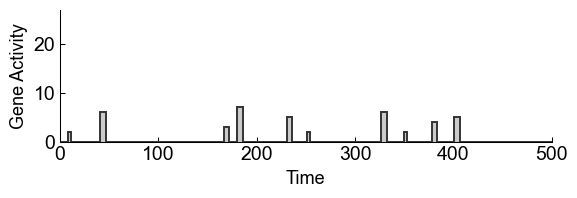

  saved  1I_no


In [44]:
y_top = trajectory_y_top()

fig = build_trajectory_trace(BURSTS_NO, y_top)
plt.show()
save_figure(fig, OUT, '1I_no')

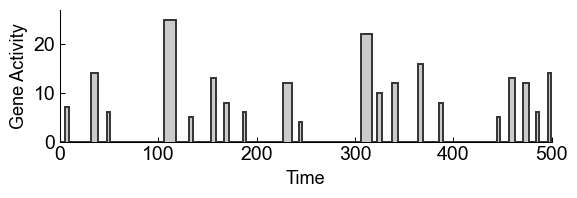

  saved  1I_yes


In [45]:
fig = build_trajectory_trace(BURSTS_YES, y_top)
plt.show()
save_figure(fig, OUT, '1I_yes')

# Figure 2: Condensation increases mean transcript output

## Panel B: Mean transcripts vs. nuclear CoF (narrow range)

Binding-only vs. condensate model, sliding-window mean over the narrow `[0.5, 2.0]`
CoF range that brackets the wild-type threshold. `v2` is the closed-box style; `v3` is
the open-box style with inline line labels, used where a legend would crowd the panel.

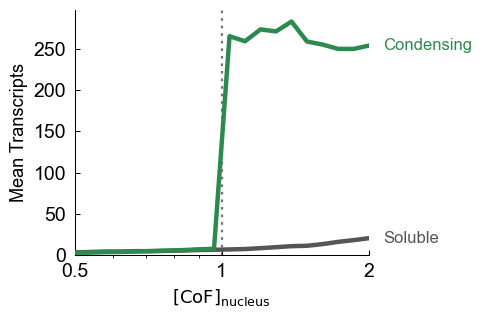

  saved  2B


In [46]:
stem, ylabel = LINE_PANEL_SPECS['transcripts']

fig = build_line_panel(rebin_narrow['transcripts'], ylabel)
plt.show()
save_figure(fig, OUT, stem)

## Panel B (wide range): Mean transcripts over the full CoF sweep

Same panel, rebinned over the full `[0.1, 10.0]` sweep so the plateau on either side of
the threshold is visible.

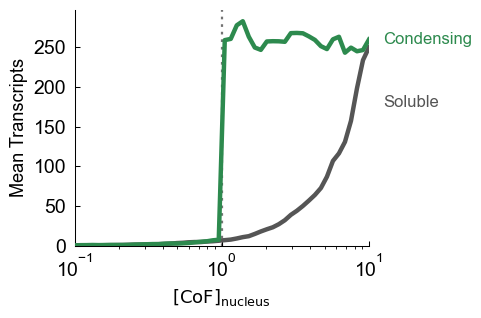

  saved  2B_wide


In [47]:
fig = build_wide_transcript_panel(rebin_wide['transcripts'])
plt.show()
save_figure(fig, OUT, '2B_wide')

## Panel C: Single-cell transcript scatter

Per-cell condensate-model transcript counts against each cell's jittered nuclear CoF
concentration (500 cells per CoF grid point).

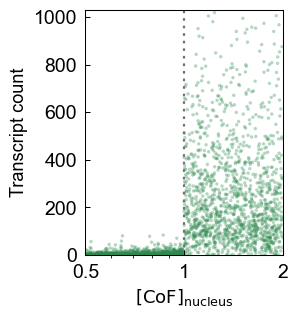

  saved  2C_black


In [48]:
stem, ylabel = SCATTER_PANEL_SPECS['transcripts']

fig = build_scatter_panel(x_flat, y_flat, 'transcripts', ylabel)
plt.show()
save_figure(fig, OUT, stem)

# Figure 4: Condensation increases frequency in the active state

## Panel A: Frequency in active state vs. nuclear CoF (narrow range)

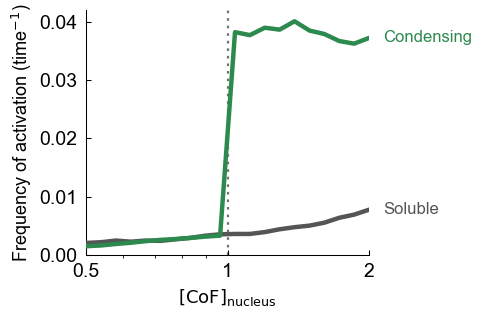

  saved  4A


In [49]:
stem, ylabel = LINE_PANEL_SPECS['burst_freq']

fig = build_line_panel(rebin_narrow['burst_freq'], ylabel)
plt.show()
save_figure(fig, OUT, stem)

## Panel C: Single-cell scatter — frequency in active state

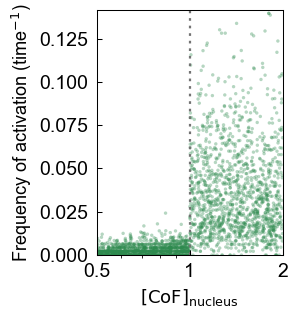

  saved  4C_black


In [50]:
stem, ylabel = SCATTER_PANEL_SPECS['burst_freq']

fig = build_scatter_panel(x_flat, y_flat, 'burst_freq', ylabel)
plt.show()
save_figure(fig, OUT, stem)

# Figure 5: Condensation increases mean transcripts per active state

## Panel A: Mean transcripts per active state vs. nuclear CoF (narrow range)

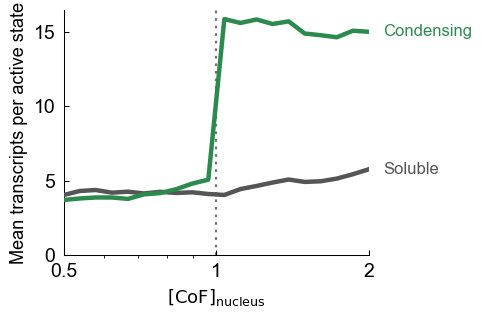

  saved  5A


In [51]:
stem, ylabel = LINE_PANEL_SPECS['burst_size']

fig = build_line_panel(rebin_narrow['burst_size'], ylabel)
plt.show()
save_figure(fig, OUT, stem)

## Panel C: Single-cell scatter — mean transcripts per active state

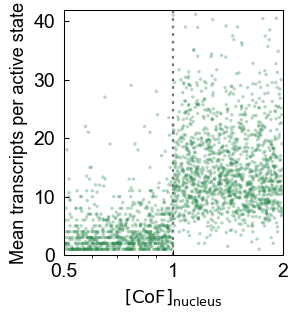

  saved  5C_black


In [52]:
stem, ylabel = SCATTER_PANEL_SPECS['burst_size']

fig = build_scatter_panel(x_flat, y_flat, 'burst_size', ylabel)
plt.show()
save_figure(fig, OUT, stem)

# Wrap-up

In [53]:
print(f'Figures saved to {OUT}/')
for p in sorted(OUT.glob('*.png')):
    print(' ', p.name)

Figures saved to /home/lqk2058/multiphase_classifiers/transcription_models/multistate_models/2026_halingstad_bursty_transcription/Figures/Output/20260724/
  1I_no.png
  1I_yes.png
  2B.png
  2B_wide.png
  2C_black.png
  4A.png
  4C_black.png
  5A.png
  5C_black.png
